Include all imports once here

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import numpy as np

import seaborn as sns



In [2]:
# Load the dataset
studentsDf = pd.read_csv('data.csv')

# Display basic information
print(studentsDf.info())
print(studentsDf.describe())

# Check class distribution
print(studentsDf['MentalHealthStatus'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PHQ9                1800 non-null   float64
 1   GAD7                1800 non-null   float64
 2   SleepHours          1800 non-null   float64
 3   ExerciseFreq        1800 non-null   float64
 4   SocialActivity      1800 non-null   float64
 5   OnlineStress        1800 non-null   float64
 6   GPA                 1800 non-null   float64
 7   FamilySupport       1800 non-null   float64
 8   ScreenTime          1800 non-null   float64
 9   AcademicStress      1800 non-null   float64
 10  DietQuality         1800 non-null   float64
 11  SelfEfficacy        1800 non-null   float64
 12  PeerRelationship    1800 non-null   float64
 13  FinancialStress     1800 non-null   float64
 14  SleepQuality        1800 non-null   float64
 15  MentalHealthStatus  1800 non-null   int64  
dtypes: flo

Explore the dataset.  Does it have nulls?  Is it mostly balanced?

In [3]:
# Check for null values in the dataframe
print(studentsDf.isnull().sum())
print("\nTotal null values:", studentsDf.isnull().sum().sum())

PHQ9                  0
GAD7                  0
SleepHours            0
ExerciseFreq          0
SocialActivity        0
OnlineStress          0
GPA                   0
FamilySupport         0
ScreenTime            0
AcademicStress        0
DietQuality           0
SelfEfficacy          0
PeerRelationship      0
FinancialStress       0
SleepQuality          0
MentalHealthStatus    0
dtype: int64

Total null values: 0


The description claims the dataset is balanced, is it truly the case?

Class distribution visualization

Class Distribution:
MentalHealthStatus
0    1283
1     517
Name: count, dtype: int64

Class Proportions:
MentalHealthStatus
0    0.712778
1    0.287222
Name: proportion, dtype: float64
Class Distribution (%):
MentalHealthStatus
0    71.28
1    28.72
Name: count, dtype: float64


<Axes: title={'center': 'Mental Health Status Distribution (%)'}, xlabel='MentalHealthStatus', ylabel='Percentage'>

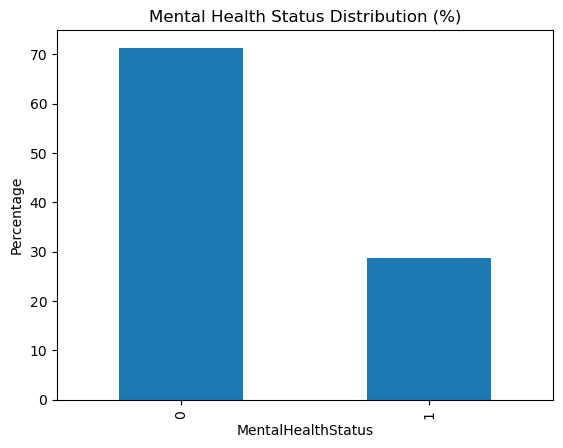

In [4]:
# Check the balance of MentalHealthStatus classes
class_distribution = studentsDf['MentalHealthStatus'].value_counts().sort_index()
print("Class Distribution:")
print(class_distribution)
print("\nClass Proportions:")
print(studentsDf['MentalHealthStatus'].value_counts(normalize=True).sort_index())

# Calculate class distribution as percentages
class_percentages = (class_distribution / len(studentsDf) * 100).round(2)
print("Class Distribution (%):")
print(class_percentages)

# Visualize as percentages
class_percentages.plot(kind='bar', title='Mental Health Status Distribution (%)', ylabel='Percentage')


Given we have well over a dozen features, studying co-variance might be better accomplished by doing a PCA, to see if there are any strong relationships between the features.

PCA Generation and visualization

Explained Variance Ratio:
[0.07758186 0.07522912 0.0718487  0.07131041 0.06959421]

Cumulative Explained Variance:
[0.07758186 0.15281098 0.22465968 0.2959701  0.36556431]


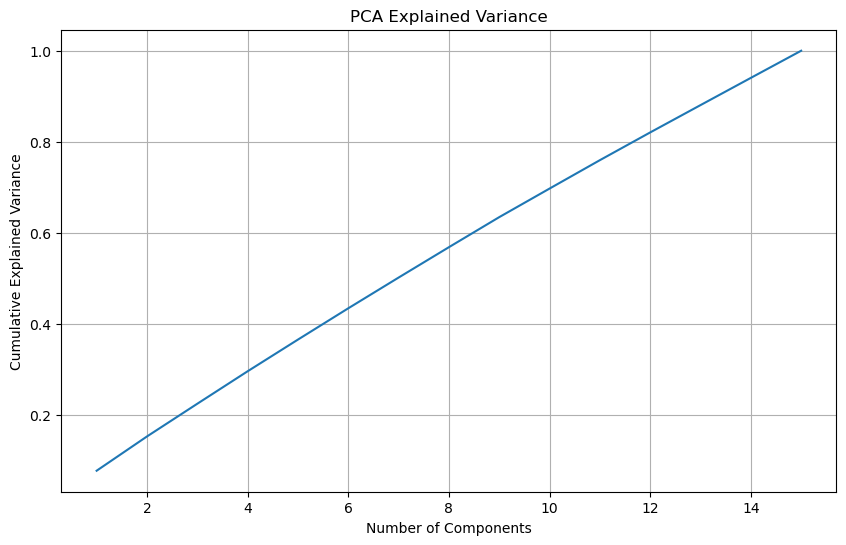

In [5]:

# Prepare the data - exclude the target variable
X = studentsDf.drop('MentalHealthStatus', axis=1)

# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Display explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_[:5])
print("\nCumulative Explained Variance:")
print(pca.explained_variance_ratio_.cumsum()[:5])

# Visualize explained variance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum())
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

Conclusion:  No strong relationships seem to emerge.  Which tracks with what might be expected.  The features do not share much common ground - atleast any that can be effectively captured by PCA.  

Looking at a correlation matrix heatmap to see if there are any pairs of features that show any sort of correlation.

Correlation Matrix

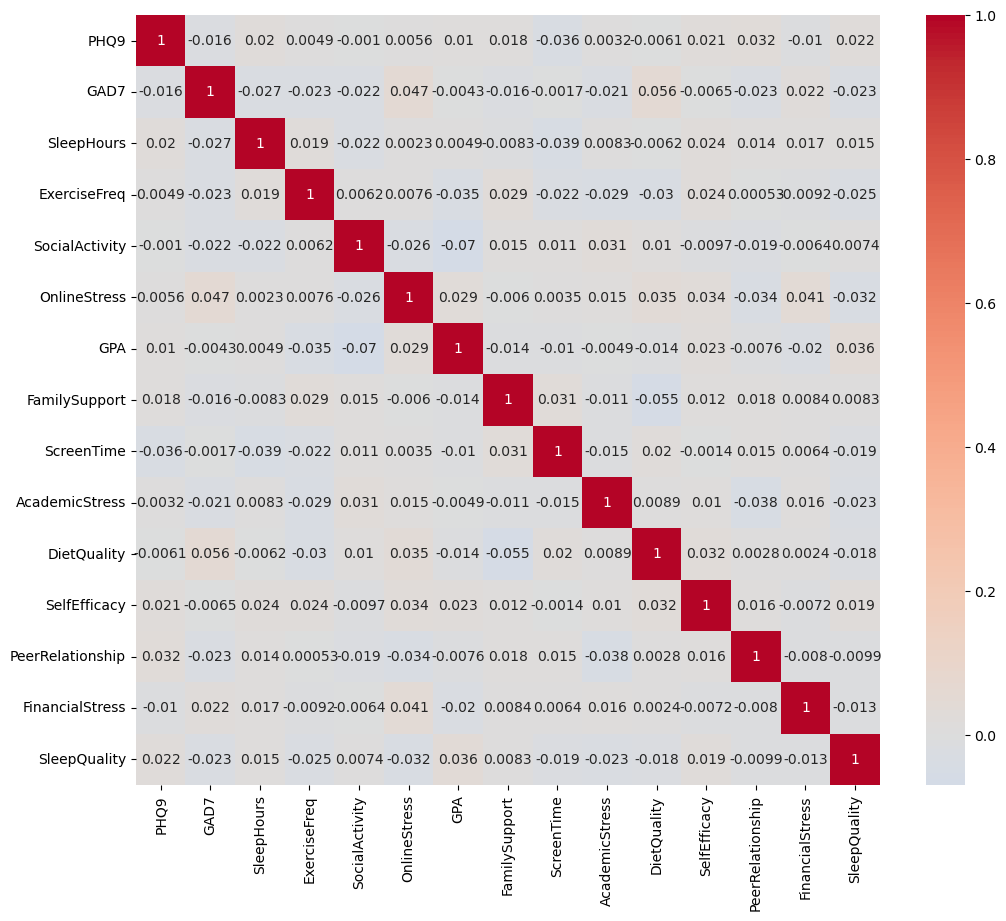

In [6]:
# Compute correlation matrix for features only (exclude target)
corr_matrix = X.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()
plt.show()

Given there is no correlation moving on to using a Kernel Density plot to determine which features likely contribute to the target value.  

Kernel Density Plot

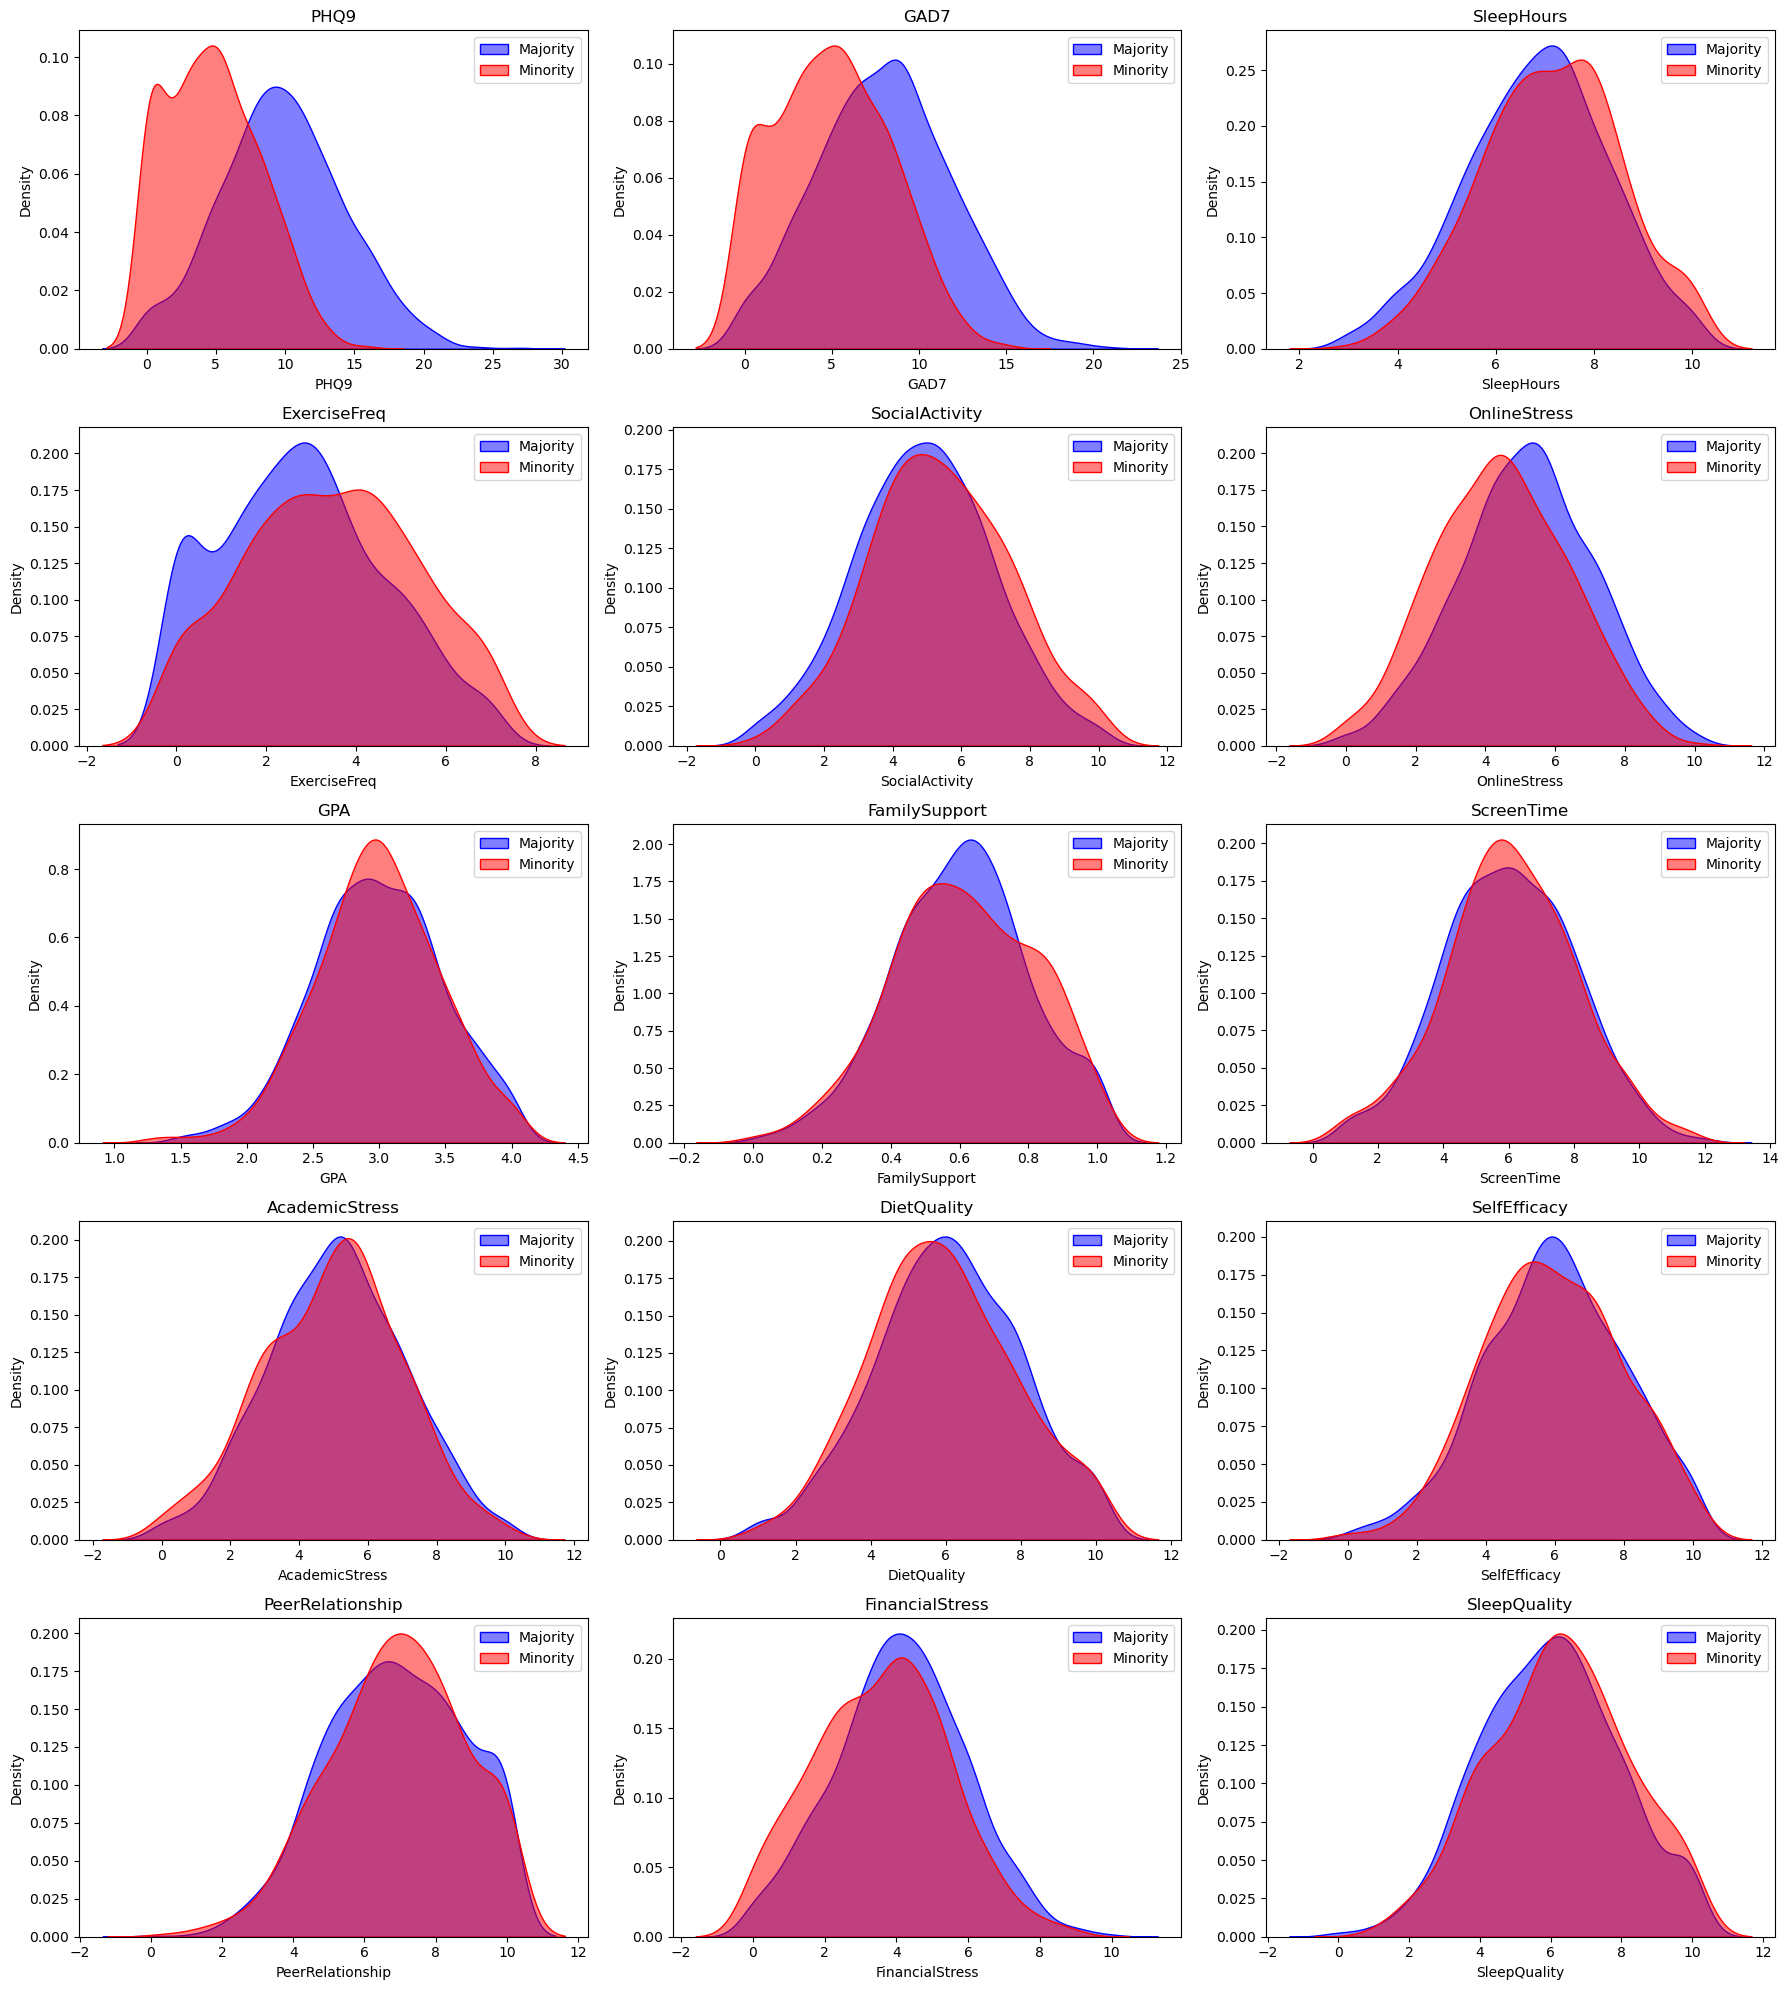

In [7]:
import seaborn as sns

import matplotlib.pyplot as plt

# Split the data by class
majority = studentsDf[studentsDf['MentalHealthStatus'] == class_distribution.index[0]]
minority = studentsDf[studentsDf['MentalHealthStatus'] == class_distribution.index[1]]

features = X.columns
n_features = len(features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(n_cols * 6, n_rows * 4))
for i, feature in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(majority[feature], label='Majority', fill=True, common_norm=False, color='blue', alpha=0.5)
    sns.kdeplot(minority[feature], label='Minority', fill=True, common_norm=False, color='red', alpha=0.5)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

Concluding from the above: it appears PHQ9 and GAD7 are likely the most important among the features that can give us useful signals while predicting mental health status. Among the other features, it might be sensible to drop GPA as it seems to have perfect overlaps between the majority and minority - even if SleepHours, SocialActivity, ScreenTime, and SleepQuality all show very very subtle differences, not quite ready to write it off as noise. It would be interesting to run the models and see if it is in agreement with this assesment.

F1 Score - computation and graphing

F1 Scores:
Dummy Classifier: 0.3700
Baseline (Decision Tree): 0.5929


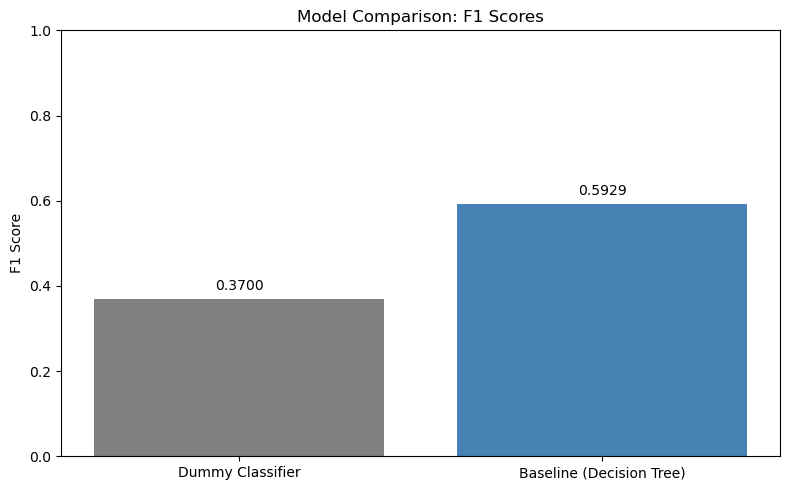

In [8]:
# Split the data
# Prepare the data - exclude the target variable
XFinal = X.drop('GPA', axis=1)
y = studentsDf['MentalHealthStatus']
X_train, X_test, y_train, y_test = train_test_split(XFinal, y, test_size=0.2, random_state=42, stratify=y)

# Dummy Classifier
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_test)
dummy_f1 = f1_score(y_test, dummy_pred)

# Decision Tree with balanced class weight (baseline model)
dt_clf = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5)
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
dt_f1 = f1_score(y_test, dt_pred)

# Compare F1 scores
results = {'Dummy Classifier': dummy_f1, 'Baseline (Decision Tree)': dt_f1}
print("F1 Scores:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['gray', 'steelblue'])
plt.ylabel('F1 Score')
plt.title('Model Comparison: F1 Scores')
plt.ylim(0, 1)
for i, (model, score) in enumerate(results.items()):
    plt.text(i, score + 0.02, f'{score:.4f}', ha='center')
plt.tight_layout()
plt.show()


Feature importance graphing

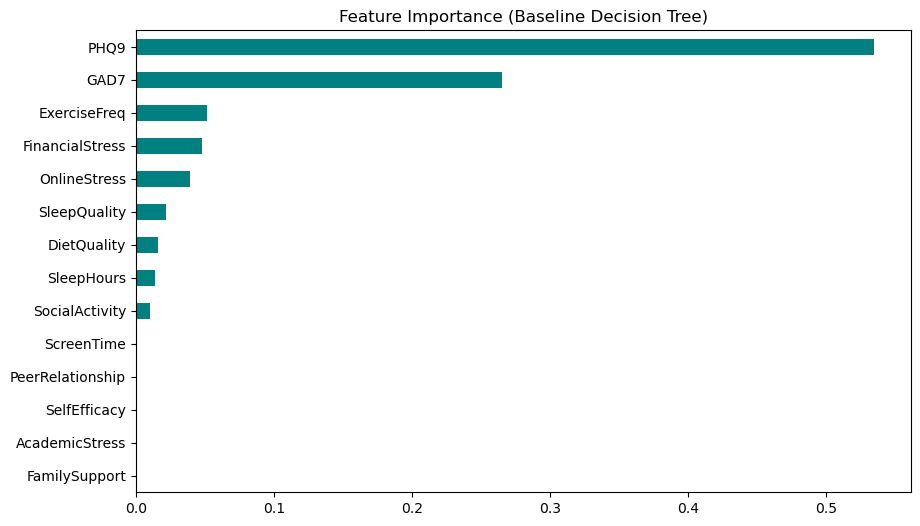

In [9]:

importances = pd.Series(dt_clf.feature_importances_, index=XFinal.columns).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance (Baseline Decision Tree)')
plt.show()